# Real estate valuation algorithm
business understanding goes here

In [140]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
  
# fetch dataset 
real_estate_valuation = fetch_ucirepo(id=477) 
  
# extract pd dataframe from dataset and describe it
df = pd.DataFrame(real_estate_valuation.data.original)
df.describe(include='all')


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


# Data preparation
The dataset is split into X (features) and Y (target), then a training set will be produced from the original values. The training set will be used to train the model and test it.

In [141]:
from sklearn.model_selection import train_test_split
# Get features and targets of the dataset
X = df.drop(['Y house price of unit area'], axis=1)
y = df['Y house price of unit area']

# Transform target value to binary based on it being more than or less than (or equal to) average price.
# This is for getting X and y values for the logistic regression
price_mean = df['Y house price of unit area'].mean()
df['Y house price of unit area'] = df['Y house price of unit area'].map(lambda v: 1 if v > price_mean else 0).astype('int64')

# Grab X and y values for logistic regression
X_log, y_log = df.iloc[:,:7], df.iloc[:,7]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(331, 7) (83, 7) (331,) (83,)


# Modeling
This dataset will be used to train two different models, a linear regression model and a logistic regression model. 

## Linear regression model

In [142]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_linear = model.predict(X_test)

In [143]:
# Find intercept and coefficient values
b0 = model.intercept_
b1 = model.coef_[0]
print(f'Intercept: {b0:.2f}, Coefficient: {b1:.4f}')

Intercept: -13170.14, Coefficient: -0.0016


The coefficient is negative in its absolute value, meaning there is a positive relationship between increasing the corresponding variable and the prediction increasing. This is however, not good enough to be conclusive, so further metrics must be gained.
For that, we use mean absolute error (MAE). 

In [144]:
from sklearn.metrics import mean_absolute_error

print("Mean absolute error (linear regression): %.2f" % mean_absolute_error(y_test, y_pred_linear))

Mean absolute error (linear regression): 5.43


In [145]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_linear)

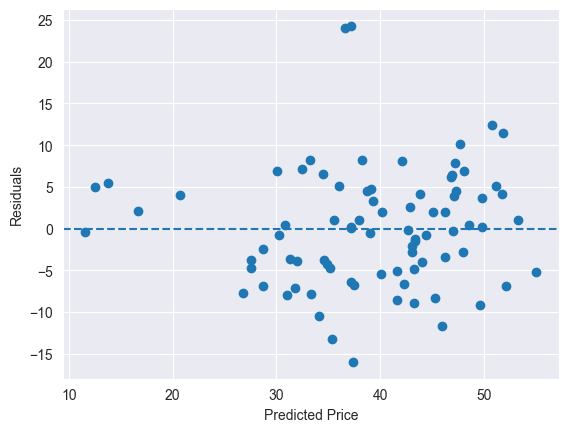

In [146]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_linear

plt.scatter(y_pred_linear, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()

In [147]:
print(f"R2 Score: {r2}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_linear):.2f}")

R2 Score: 0.6517219654355003
MAE: 5.43


These metrics show that the model is moderately accurate. An R2 score of 0.65 is a bit below the desired result, but is not bad. MAE score of 5.43 means that the model's prediction varies by about 54k Taiwanese dollars from the actual price. This variation is about ~1450€ when converted from Taiwanese dollars.

## Logistic regression model
The alternative model uses logistic regression, which is a sigmoid function (s-shaped). It can be visualized like this:

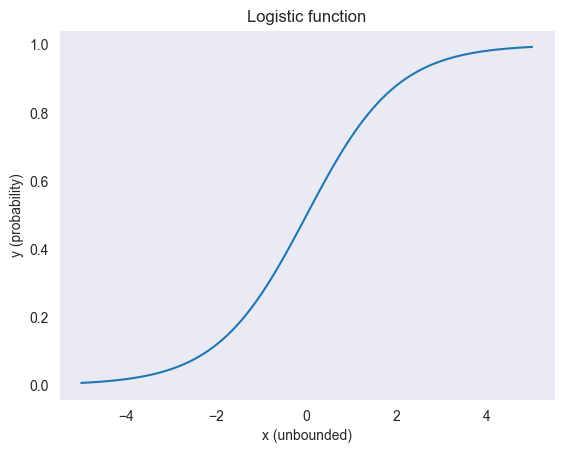

In [148]:
# visualize the sigmoid function
import numpy as np

x = np.linspace(-5, 5, 100)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.xlabel('x (unbounded)')
plt.ylabel('y (probability)')
plt.title('Logistic function')
plt.grid()

plt.show()

Logistic regression uses linear regression to predict a continuous value, that is transformed into a probability by using the logistic function pictured above. For the purpose of this algorithm, it will used to convert the Y target into a binary value.
Logistic regression requires the targets to be standardized.

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# standardize the features
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_log), columns=X_log.columns)
X.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,-1.727872,-0.823683,1.255628,-0.792495,2.007407,1.125430,0.448762
1,-1.719505,-0.823683,0.157086,-0.616612,1.667503,0.912444,0.401139
2,-1.711137,1.541151,-0.387791,-0.414015,0.307885,1.486860,0.688183
3,-1.702770,1.246435,-0.387791,-0.414015,0.307885,1.486860,0.688183
4,-1.694402,-1.121951,-1.117223,-0.549997,0.307885,0.834188,0.592937


In [150]:
# build and fit model
reg = LogisticRegression(solver='lbfgs')
reg.fit(X_log, y_log)

print("Coefficients: ",reg.coef_)
print("Intercept: ", reg.intercept_)

Coefficients:  [[-0.00146548  0.01607863 -0.05395414 -0.00220209  0.22121867  0.26410957
  -0.30241327]]
Intercept:  [-0.00213374]
